Download complete in 15s (4.9 MB)
Extracting EDF parameters from /Users/rishabhkumar/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S010/S010R04.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19679  =      0.000 ...   122.994 secs...
Extracting EDF parameters from /Users/rishabhkumar/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S010/S010R06.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19679  =      0.000 ...   122.994 secs...
Extracting EDF parameters from /Users/rishabhkumar/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S010/S010R07.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19679  =      0.000 ...   122.994 secs...
Extracting EDF parameters from /Users/rishabhkumar/mne_data/MNE-eegbci-data/files/eegmmidb/1.0.0/S010/S010R08.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure..

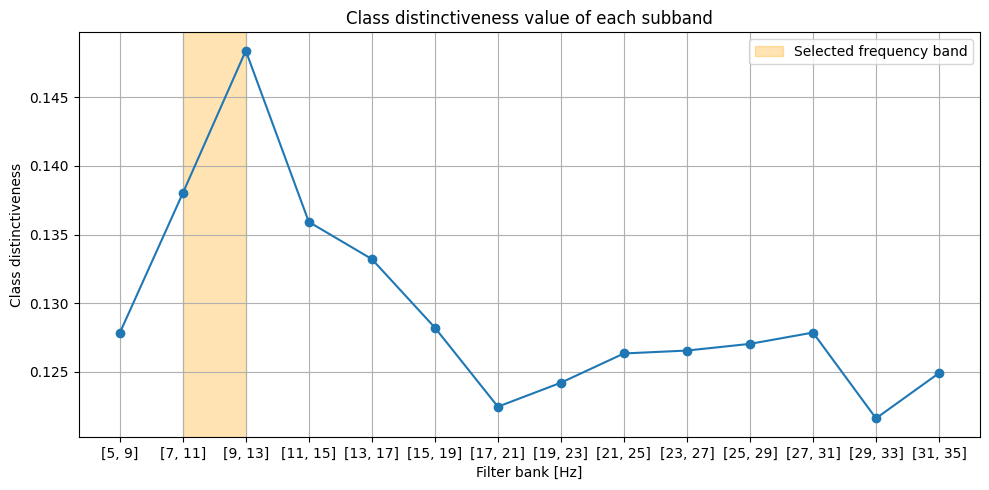

Optimal frequency band for this subject is 7.0 - 13.0 Hz


In [4]:
"""
=========================================================================
Frequency band selection on the manifold for motor imagery classification
=========================================================================

Find optimal frequency band using class distinctiveness measure on
the manifold and compare classification performance for motor imagery
data to the baseline with no frequency band selection [1]_.


"""
# Authors: Maria Sayu Yamamoto <maria-sayu.yamamoto@universite-paris-saclay.fr>
#
# License: BSD (3-clause)

from time import time

from matplotlib import pyplot as plt
from mne import Epochs, pick_types, events_from_annotations
from mne.io import concatenate_raws
from mne.io.edf import read_raw_edf
from mne.datasets import eegbci
import numpy as np
from sklearn.model_selection import cross_val_score, ShuffleSplit

from pyriemann.classification import MDM
from pyriemann.estimation import Covariances
from helpers.frequencybandselection_helpers import freq_selection_class_dis


###############################################################################
# Set basic parameters and read data
# ----------------------------------

tmin, tmax = 0.5, 2.5
event_id = dict(T1=2, T2=3)
subject = 10
runs = [4, 6, 7, 8]  # motor imagery: left hand vs right hand

raw_files = [
    read_raw_edf(f, preload=True)
    for f in eegbci.load_data(subject, runs, update_path=True)
]
raw = concatenate_raws(raw_files)
picks = pick_types(
    raw.info, meg=False, eeg=True, stim=False, eog=False, exclude="bads")
# subsample elecs
picks = picks[::2]

# cross validation
cv = ShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

###############################################################################
# Baseline pipeline without frequency band selection
# ---------------------------------------------------
#
# Apply band-pass filter using a wide frequency band, 5-35 Hz.
# Train and evaluate classifier.
t0 = time()
raw_filter = raw.copy().filter(5., 35., method="iir", picks=picks,
                               verbose=False)

events, _ = events_from_annotations(raw_filter, event_id, verbose=False)

# Read epochs (train will be done only between 0.5 and 2.5 s)
epochs = Epochs(
    raw_filter,
    events,
    event_id,
    tmin,
    tmax,
    proj=True,
    picks=picks,
    baseline=None,
    preload=True,
    verbose=False)
labels = epochs.events[:, -1] - 2

# Get epochs
epochs_data_baseline = epochs.get_data(units="uV", copy=False)

# Compute covariance matrices
cov_data_baseline = Covariances().transform(epochs_data_baseline)

# Set classifier
model = MDM(metric=dict(mean="riemann", distance="riemann"))

# Classification with minimum distance to mean
acc_baseline = cross_val_score(model, cov_data_baseline, labels,
                               cv=cv, n_jobs=1)
t1 = time() - t0

###############################################################################
# Pipeline with a frequency band selection based on the class distinctiveness
# ---------------------------------------------------------------------------
#
# Step1: Select frequency band maximizing class distinctiveness on
# training set.
#
# Define parameters for frequency band selection
t2 = time()
freq_band = [5., 35.]
sub_band_width = 4.
sub_band_step = 2.
alpha = 0.4

# Select frequency band using training set
best_freq, all_class_dis = \
    freq_selection_class_dis(raw, freq_band, sub_band_width,
                             sub_band_step, alpha,
                             tmin, tmax,
                             picks, event_id,
                             cv,
                             return_class_dis=True, verbose=False)

print(f"Selected frequency band : {best_freq[0][0]} - {best_freq[0][1]} Hz")

###############################################################################
# Step2: Train classifier using selected frequency band and evaluate
# performance using test set

# Apply band-pass filter using the best frequency band
best_raw_filter = raw.copy().filter(best_freq[0][0], best_freq[0][1],
                                    method="iir", picks=picks,
                                    verbose=False)

events, _ = events_from_annotations(best_raw_filter, event_id, verbose=False)

# Read epochs (train will be done only between 0.5 and 2.5s)
epochs = Epochs(
    best_raw_filter,
    events,
    event_id,
    tmin,
    tmax,
    proj=True,
    picks=picks,
    baseline=None,
    preload=True,
    verbose=False,
)

# Get epochs
epochs_data_train = epochs.get_data(units="uV", copy=False)

# Estimate covariance matrices
cov_data = Covariances().transform(epochs_data_train)

# Classification with minimum distance to mean
acc = cross_val_score(model, cov_data, labels, cv=cv, n_jobs=1)
t3 = time() - t2

###############################################################################
# Compare pipelines: accuracies and training times
# ------------------------------------------------

print("Classification accuracy without frequency band selection: "
      + f"{acc_baseline[0]:.02f}")
print("Total computational time without frequency band selection: "
      + f"{t1:.5f} s")
print("Classification accuracy with frequency band selection: "
      + f"{acc[0]:.02f}")
print("Total computational time with frequency band selection: "
      + f"{t3:.5f} s")

###############################################################################
# Plot selected frequency bands
# -----------------------------
#
# Plot the class distinctiveness values for each sub_band,
# along with the highlight of the finally selected frequency band.

subband_fmin = list(np.arange(freq_band[0],
                              freq_band[1] - sub_band_width + 1.,
                              sub_band_step))
subband_fmax = list(np.arange(freq_band[0] + sub_band_width,
                              freq_band[1] + 1., sub_band_step))
n_subband = len(subband_fmin)

x = list(range(0, n_subband, 1))
fig = plt.figure(figsize=(10, 5))

freq_start = subband_fmin.index(best_freq[0][0])
freq_end = subband_fmax.index(best_freq[0][1])

plt.subplot(1, 1, 1)
plt.grid()
plt.plot(x, all_class_dis[0], marker="o")
plt.xticks(list(range(0, 14, 1)),
           [[int(i), int(j)] for i, j in zip(subband_fmin, subband_fmax)])

plt.axvspan(freq_start, freq_end, color="orange", alpha=0.3,
            label="Selected frequency band")
plt.ylabel("Class distinctiveness")
plt.xlabel("Filter bank [Hz]")
plt.title("Class distinctiveness value of each subband")
plt.legend(loc="upper right")

fig.tight_layout()
plt.show()

print("Optimal frequency band for this subject is "
      f"{best_freq[0][0]} - {best_freq[0][1]} Hz")

###############################################################################
# References
# ----------
# .. [1] `Class-distinctiveness-based frequency band selection on the
#    Riemannian manifold for oscillatory activity-based BCIs: preliminary
#    results
#    <https://hal.archives-ouvertes.fr/hal-03641137/>`_
#    M. S. Yamamoto, F. Lotte, F. Yger, and S. Chevallier.
#    44th Annual International Conference of the IEEE Engineering
#    in Medicine & Biology Society (EMBC2022), 2022.